# Fairness comparison: global performance vs. fairness trade-off

Compares several aggregation strategies from `fairness_strategy.py`:
- `fedavg`        -- standard num_examples-weighted FedAvg (baseline)
- `fedavguniform` -- equal weight per client
- `fedavgqffl_qX` -- q-FFL with a chosen q (run several q values)
- `fedavgadaptiveqffl` -- q-FFL with an adaptive q

In [4]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Map a human-readable label -> the strategy tag used in the log filenames
# (i.e. fairness_log_<tag>.csv). Adjust to whatever you actually ran.
STRATEGY_RUNS = {
    "FedAvg (baseline)":     "fedavgqffl_q0p0",  # q=0 == plain FedAvg weighting, but logged
    "Uniform weighting":     "fedavguniform",
    "q-FFL (q=0.5)":         "fedavgqffl_q0p5",
    "q-FFL (q=1.0)":         "fedavgqffl_q1p0",
    "q-FFL (q=2.0)":         "fedavgqffl_q2p0",
    "q-FFL (q=5.0)":         "fedavgqffl_q5p0",
    "adaptive q-FFL":        "fedavgadaptiveqffl",
}

In [6]:
def load_run(tag):
    csv_path = Path(f"../fairness_log_{tag}.csv")
    jsonl_path = Path(f"../fairness_metrics_{tag}.jsonl")
    df = pd.read_csv(csv_path)
    records = []
    with open(jsonl_path) as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    metrics_df = pd.DataFrame(records)
    return df, metrics_df

runs = {label: load_run(tag) for label, tag in STRATEGY_RUNS.items()}

FileNotFoundError: [Errno 2] No such file or directory: '..\\fairness_log_fedavgqffl_q0p0.csv'

## Summary table: final-round global performance vs. fairness

In [ ]:
rows = []
for label, (df, metrics_df) in runs.items():
    final_round = df["round"].max()
    final_df = df[df["round"] == final_round]

    # "global performance" = num_examples-weighted average loss,
    # kept the same way across strategies for a fair comparison
    weighted_global_loss = np.average(final_df["valid_loss"], weights=final_df["num_examples"])

    final_metrics = metrics_df[metrics_df["round"] == metrics_df["round"].max()].iloc[0]

    rows.append({
        "strategy": label,
        "global_weighted_loss": weighted_global_loss,
        "jain_index": final_metrics["jain_index"],
        "variance": final_metrics["variance"],
        "worst_client_loss": final_metrics["worst_client_loss"],
        "best_client_loss": final_metrics["best_client_loss"],
    })

summary_df = pd.DataFrame(rows).set_index("strategy")
summary_df

,global_weighted_loss,jain_index,variance,worst_client_loss,best_client_loss
strategy,,,,,
FedAvg (baseline),1207.214920,0.501932,2.874326e+06,5301.326660,535.537109
Uniform weighting,1190.939024,0.512967,2.605546e+06,5072.703613,539.425415
q-FFL (q=0.5),1173.552215,0.520108,2.465411e+06,4979.397461,544.355652
q-FFL (q=1.0),1186.677649,0.529603,2.381427e+06,4947.946777,573.163025
q-FFL (q=2.0),1240.939011,0.587479,1.896563e+06,4571.358887,665.785889
q-FFL (q=5.0),1362.407762,0.655854,1.560452e+06,4269.484375,805.047913
adaptive q-FFL,1178.421159,0.532937,2.313061e+06,4876.433594,570.988220


## Trade-off plot: global performance vs. fairness

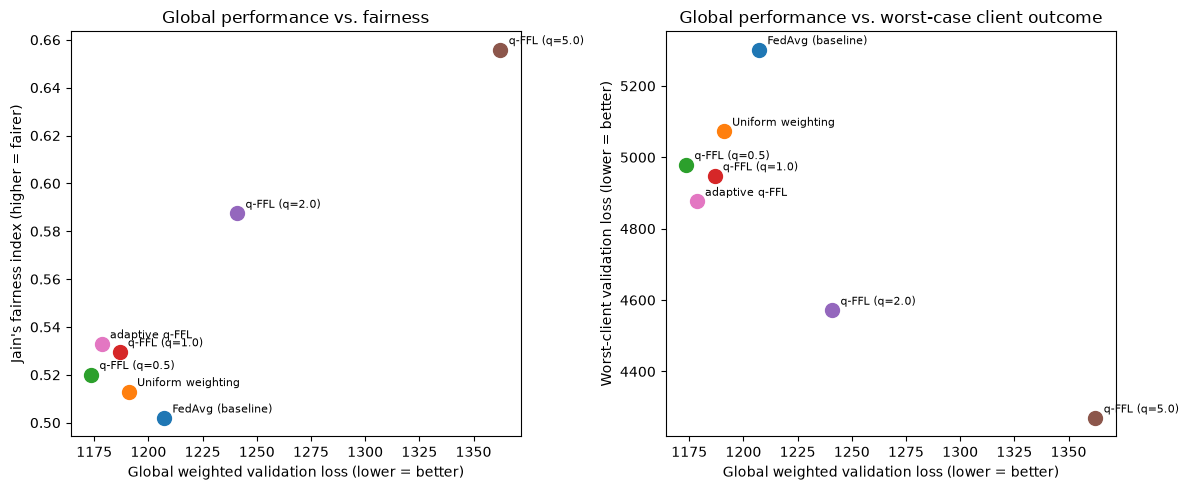

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for label, row in summary_df.iterrows():
    axes[0].scatter(row["global_weighted_loss"], row["jain_index"], s=100)
    axes[0].annotate(label, (row["global_weighted_loss"], row["jain_index"]),
                      textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[0].set_xlabel("Global weighted validation loss (lower = better)")
axes[0].set_ylabel("Jain's fairness index (higher = fairer)")
axes[0].set_title("Global performance vs. fairness")

for label, row in summary_df.iterrows():
    axes[1].scatter(row["global_weighted_loss"], row["worst_client_loss"], s=100)
    axes[1].annotate(label, (row["global_weighted_loss"], row["worst_client_loss"]),
                      textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[1].set_xlabel("Global weighted validation loss (lower = better)")
axes[1].set_ylabel("Worst-client validation loss (lower = better)")
axes[1].set_title("Global performance vs. worst-case client outcome")

plt.tight_layout()
plt.show()

## Per-client loss vs. client size, one line per strategy

Shows directly whether reweighting flattens the size-vs-loss relationship
identified in `fairness_diagnosis.ipynb`.

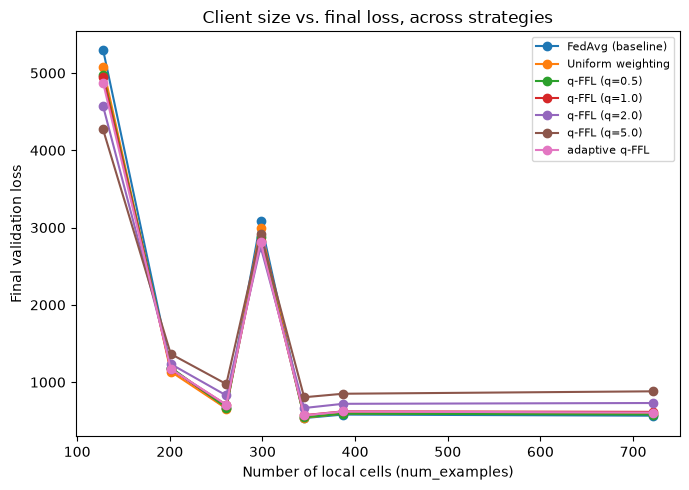

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
for label, (df, _) in runs.items():
    final_round = df["round"].max()
    final_df = df[df["round"] == final_round].sort_values("num_examples")
    ax.plot(final_df["num_examples"], final_df["valid_loss"], marker="o", label=label)
ax.set_xlabel("Number of local cells (num_examples)")
ax.set_ylabel("Final validation loss")
ax.set_title("Client size vs. final loss, across strategies")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Fairness index over training, across strategies

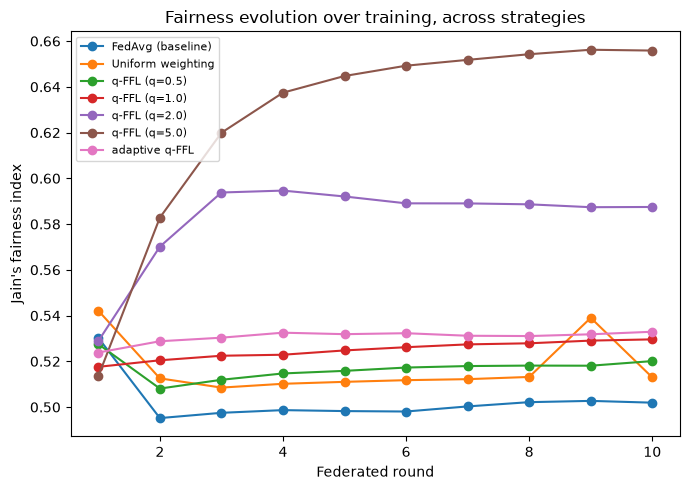

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
for label, (_, metrics_df) in runs.items():
    ax.plot(metrics_df["round"], metrics_df["jain_index"], marker="o", label=label)
ax.set_xlabel("Federated round")
ax.set_ylabel("Jain's fairness index")
ax.set_title("Fairness evolution over training, across strategies")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()